# pdfplumber + python-docx Benchmark

**Purpose:** Evaluate whether `pdfplumber` + `python-docx` (both MIT-licensed) can convert 60-page PDFs within the 90-second Celery task timeout, as an alternative to `pdf2docx` (GPL/AGPL).

**Libraries:**
- [pdfplumber](https://github.com/jsvine/pdfplumber) — MIT · PDF text & table extraction built on pdfminer.six
- [python-docx](https://github.com/python-openxml/python-docx) — MIT · DOCX generation
- [PyMuPDF](https://github.com/pymupdf/PyMuPDF) — AGPL · **Only used for generating test PDFs**, not in the conversion pipeline

**Conversion pipeline:**
1. Open PDF with pdfplumber
2. For each page: extract text blocks + detect/extract tables
3. Build DOCX using python-docx (paragraphs, tables, images)
4. Save DOCX

---

In [1]:
import fitz  # PyMuPDF — ONLY for generating test PDFs
import io
import os
import struct
import time
import zlib

import pdfplumber
from docx import Document
from docx.shared import Inches, Pt, Emu
from docx.enum.text import WD_ALIGN_PARAGRAPH

PAGES = 60
OUTPUT_DIR = "/Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []


def convert_with_pdfplumber(pdf_path, docx_path):
    """
    Convert PDF → DOCX using pdfplumber (text + tables) + python-docx.

    Strategy:
    - For each page, find tables and their bounding boxes
    - Extract text that is NOT inside any table bbox
    - Render non-table text as paragraphs, tables as Word tables
    - Add a page break between pages
    """
    doc = Document()

    with pdfplumber.open(pdf_path) as pdf:
        for page_idx, page in enumerate(pdf.pages):
            if page_idx > 0:
                doc.add_page_break()

            # 1. Find tables and their bounding boxes
            tables = page.find_tables()
            table_bboxes = [t.bbox for t in tables]

            # 2. Extract words, filtering out those inside table regions
            words = page.extract_words(keep_blank_chars=True, extra_attrs=["size", "fontname"])

            # Group words into lines by clustering on y-coordinate (top)
            non_table_words = []
            for w in words:
                inside_table = False
                for bbox in table_bboxes:
                    # bbox = (x0, top, x1, bottom)
                    if (bbox[0] - 2 <= w["x0"] <= bbox[2] + 2 and
                        bbox[1] - 2 <= w["top"] <= bbox[3] + 2):
                        inside_table = True
                        break
                if not inside_table:
                    non_table_words.append(w)

            # Group words into lines by y-position (top coordinate, rounded)
            lines = {}
            for w in non_table_words:
                line_key = round(w["top"], 1)
                if line_key not in lines:
                    lines[line_key] = []
                lines[line_key].append(w)

            # Sort lines by y, words within each line by x
            sorted_y = sorted(lines.keys())

            # Build a list of content items in vertical order: (y_pos, type, data)
            content_items = []

            for y in sorted_y:
                line_words = sorted(lines[y], key=lambda w: w["x0"])
                line_text = " ".join(w["text"] for w in line_words)
                avg_size = sum(w["size"] for w in line_words) / len(line_words)
                content_items.append((y, "text", line_text, avg_size))

            for table in tables:
                content_items.append((table.bbox[1], "table", table.extract(), 0))

            # Sort everything by y position
            content_items.sort(key=lambda x: x[0])

            # 3. Render into DOCX
            for _, item_type, data, size in content_items:
                if item_type == "text":
                    p = doc.add_paragraph()
                    run = p.add_run(data)
                    # Map PDF font sizes to Word: treat >= 14pt as headings
                    if size >= 16:
                        p.style = doc.styles["Heading 1"]
                    elif size >= 14:
                        p.style = doc.styles["Heading 2"]
                    else:
                        run.font.size = Pt(size)
                elif item_type == "table":
                    rows = data
                    if not rows or not rows[0]:
                        continue
                    num_rows = len(rows)
                    num_cols = max(len(r) for r in rows)
                    tbl = doc.add_table(rows=num_rows, cols=num_cols, style="Table Grid")
                    for i, row in enumerate(rows):
                        for j, cell_val in enumerate(row):
                            if j < num_cols:
                                tbl.cell(i, j).text = cell_val or ""

    doc.save(docx_path)


def run_benchmark(name, pdf_path, docx_path):
    """Convert a PDF to DOCX using pdfplumber and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    start = time.time()
    convert_with_pdfplumber(pdf_path, docx_path)
    elapsed = time.time() - start
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    results.append({
        "scenario": name,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
    })
    print(f"  PDF size:    {pdf_kb:,.0f} KB  →  {pdf_path}")
    print(f"  DOCX size:   {docx_kb:,.0f} KB  →  {docx_path}")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    return elapsed


print(f"PyMuPDF version (test PDF generation only): {fitz.version}")
print(f"pdfplumber version: {pdfplumber.__version__}")
print(f"Output directory: {OUTPUT_DIR}/")
print(f"Generating {PAGES}-page test PDFs...")

PyMuPDF version (test PDF generation only): ('1.24.3', '1.24.2', '20240509000001')
pdfplumber version: 0.11.9
Output directory: /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/
Generating 60-page test PDFs...


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

**Best case** — no tables, no images, just text extraction and paragraph formatting.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "text_only.pdf")
docx_path = os.path.join(OUTPUT_DIR, "text_only.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_benchmark("Text-only", pdf_path, docx_path)

Scenario 1: Text-Only (25 lines/page)


  PDF size:    398 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/text_only.pdf
  DOCX size:   41 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/text_only.docx
  Total time:  1.84s
  Per page:    0.031s
  Verdict:     Safe


1.8426828384399414

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5×4 table** with cell data, and 8 more text paragraphs below.

Represents a typical business document with occasional data tables.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "simple_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "simple_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_benchmark("Text + simple tables", pdf_path, docx_path)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  PDF size:    593 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/simple_tables.pdf
  DOCX size:   39 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/simple_tables.docx
  Total time:  2.08s
  Per page:    0.035s
  Verdict:     Safe


2.0787811279296875

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. This was the **primary bottleneck** for pdf2docx (92s, exceeded 90s timeout). pdfplumber uses a different table detection algorithm (line intersection) — let's see if it's faster.

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "dense_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "dense_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print()
run_benchmark("Dense tables (worst case)", pdf_path, docx_path)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640



  PDF size:    2,301 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/dense_tables.pdf
  DOCX size:   50 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/dense_tables.docx
  Total time:  6.77s
  Per page:    0.113s
  Verdict:     Safe


6.765649795532227

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.**

> **Note:** pdfplumber does not natively extract images. For image extraction we'd need to use `pypdf` or `pikepdf` (both BSD/MIT-compatible). This benchmark tests whether pdfplumber can handle pages that *contain* images without choking, even though the images won't be transferred to the DOCX.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "mixed_content.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_benchmark("Mixed content", pdf_path, docx_path)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:    730 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_content.pdf
  DOCX size:   39 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_content.docx
  Total time:  1.86s
  Per page:    0.031s
  Verdict:     Safe


1.8580663204193115

---
## Scenario 5: Mixed Content with Image Extraction (pypdf + pdfplumber + python-docx)

Same PDF as Scenario 4, but this time we **also extract and embed images** using `pypdf` (BSD license) for image extraction alongside pdfplumber for text/tables.

This tests the full MIT/BSD-compatible pipeline with image support.

In [6]:
from pypdf import PdfReader

def convert_with_images(pdf_path, docx_path):
    """
    Convert PDF → DOCX using:
      - pdfplumber for text + tables (MIT)
      - pypdf for image extraction (BSD)
      - python-docx for DOCX generation (MIT)
    """
    doc_out = Document()
    reader = PdfReader(pdf_path)

    with pdfplumber.open(pdf_path) as pdf:
        for page_idx, page in enumerate(pdf.pages):
            if page_idx > 0:
                doc_out.add_page_break()

            tables = page.find_tables()
            table_bboxes = [t.bbox for t in tables]

            words = page.extract_words(keep_blank_chars=True, extra_attrs=["size", "fontname"])

            non_table_words = []
            for w in words:
                inside_table = False
                for bbox in table_bboxes:
                    if (bbox[0] - 2 <= w["x0"] <= bbox[2] + 2 and
                        bbox[1] - 2 <= w["top"] <= bbox[3] + 2):
                        inside_table = True
                        break
                if not inside_table:
                    non_table_words.append(w)

            lines = {}
            for w in non_table_words:
                line_key = round(w["top"], 1)
                if line_key not in lines:
                    lines[line_key] = []
                lines[line_key].append(w)

            sorted_y = sorted(lines.keys())

            content_items = []
            for y in sorted_y:
                line_words = sorted(lines[y], key=lambda w: w["x0"])
                line_text = " ".join(w["text"] for w in line_words)
                avg_size = sum(w["size"] for w in line_words) / len(line_words)
                content_items.append((y, "text", line_text, avg_size))

            for table in tables:
                content_items.append((table.bbox[1], "table", table.extract(), 0))

            # Extract images from this page via pypdf
            pypdf_page = reader.pages[page_idx]
            page_images = []
            if "/XObject" in (pypdf_page.get("/Resources") or {}):
                xobjects = pypdf_page["/Resources"]["/XObject"].get_object()
                for obj_name in xobjects:
                    obj = xobjects[obj_name].get_object()
                    if obj.get("/Subtype") == "/Image":
                        try:
                            img_data = obj.get_data()
                            page_images.append(img_data)
                        except Exception:
                            pass

            # Place images roughly in the middle of content
            if page_images:
                mid_y = page.height / 2
                for img_data in page_images:
                    content_items.append((mid_y, "image", img_data, 0))

            content_items.sort(key=lambda x: x[0])

            for _, item_type, data, size in content_items:
                if item_type == "text":
                    p = doc_out.add_paragraph()
                    run = p.add_run(data)
                    if size >= 16:
                        p.style = doc_out.styles["Heading 1"]
                    elif size >= 14:
                        p.style = doc_out.styles["Heading 2"]
                    else:
                        run.font.size = Pt(size)
                elif item_type == "table":
                    rows = data
                    if not rows or not rows[0]:
                        continue
                    num_rows = len(rows)
                    num_cols = max(len(r) for r in rows)
                    tbl = doc_out.add_table(rows=num_rows, cols=num_cols, style="Table Grid")
                    for i, row in enumerate(rows):
                        for j, cell_val in enumerate(row):
                            if j < num_cols:
                                tbl.cell(i, j).text = cell_val or ""
                elif item_type == "image":
                    try:
                        img_stream = io.BytesIO(data)
                        doc_out.add_picture(img_stream, width=Inches(2.5))
                    except Exception:
                        doc_out.add_paragraph("[Image extraction failed]")

    doc_out.save(docx_path)


# Use the same mixed content PDF from Scenario 4
pdf_path = os.path.join(OUTPUT_DIR, "mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "mixed_with_images.docx")

pdf_kb = os.path.getsize(pdf_path) / 1024
start = time.time()
convert_with_images(pdf_path, docx_path)
elapsed = time.time() - start
docx_kb = os.path.getsize(docx_path) / 1024
per_page = elapsed / PAGES
verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")

results.append({
    "scenario": "Mixed + images (pypdf)",
    "pdf_kb": pdf_kb,
    "docx_kb": docx_kb,
    "total_s": elapsed,
    "per_page_s": per_page,
    "verdict": verdict,
})

print("Scenario 5: Mixed Content + Image Extraction")
print("=" * 50)
print(f"  PDF size:    {pdf_kb:,.0f} KB  →  {pdf_path}")
print(f"  DOCX size:   {docx_kb:,.0f} KB  →  {docx_path}")
print(f"  Total time:  {elapsed:.2f}s")
print(f"  Per page:    {per_page:.3f}s")
print(f"  Verdict:     {verdict}")

Scenario 5: Mixed Content + Image Extraction
  PDF size:    730 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_content.pdf
  DOCX size:   39 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_with_images.docx
  Total time:  1.88s
  Per page:    0.031s
  Verdict:     Safe


---
## Scenario 6: Two-Column Layout (MSA-style)

60 pages of **two-column text** with section headings — the layout commonly found in Master Service Agreements, legal contracts, and insurance documents.

Tests pdfplumber's word extraction and line grouping for multi-column layouts. pdfplumber extracts words with (x, y) coordinates, so the line-grouping logic should handle columns correctly if words are clustered by y-position.

In [7]:
from reportlab.platypus import BaseDocTemplate, Frame, PageTemplate, Paragraph as RLParagraph, Spacer as RLSpacer
from reportlab.lib.pagesizes import letter as rl_letter
from reportlab.lib.units import inch as rl_inch
from reportlab.lib.styles import getSampleStyleSheet as rlGetStyles, ParagraphStyle
from reportlab.lib.enums import TA_JUSTIFY

pdf_path = os.path.join(OUTPUT_DIR, "two_column_msa.pdf")
docx_path = os.path.join(OUTPUT_DIR, "two_column_msa.docx")

msa_sections = [
    ("1. DEFINITIONS", [
        '"Agreement" means this Master Service Agreement, including all exhibits and schedules attached hereto.',
        '"Confidential Information" means any information disclosed by one party to the other party, either directly or indirectly, in writing, orally, or by inspection of tangible objects.',
        '"Effective Date" means the date first written above or the date of the last signature below, whichever is later.',
        '"Intellectual Property" means all patents, copyrights, trademarks, trade secrets, and other proprietary rights.',
        '"Services" means the professional services to be provided by Service Provider as described in each Statement of Work.',
        '"Term" means the period commencing on the Effective Date and continuing until terminated in accordance with Section 8.',
    ]),
    ("2. SCOPE OF SERVICES", [
        "Service Provider shall perform the Services described in each Statement of Work executed by both parties.",
        "Each Statement of Work shall describe the scope, timeline, deliverables, fees, and payment terms.",
        "Service Provider shall assign qualified personnel with appropriate skills and experience to perform the Services.",
        "Client may request changes to the Services by submitting a written change order to Service Provider.",
        "Service Provider shall use commercially reasonable efforts to accommodate such change requests.",
    ]),
    ("3. COMPENSATION AND PAYMENT", [
        "Client shall pay Service Provider the fees set forth in each Statement of Work.",
        "Unless otherwise specified, all invoices shall be due and payable within thirty (30) days of receipt.",
        "Late payments shall accrue interest at the rate of one and one-half percent (1.5%) per month.",
        "Service Provider shall submit itemized invoices on a monthly basis detailing the Services performed.",
        "Client shall reimburse Service Provider for reasonable travel and out-of-pocket expenses pre-approved in writing.",
        "All fees are exclusive of applicable taxes, which shall be the responsibility of Client.",
    ]),
    ("4. CONFIDENTIALITY", [
        "Each party agrees to maintain the confidentiality of all Confidential Information received from the other party.",
        "Neither party shall disclose Confidential Information to any third party without prior written consent.",
        "The obligations of confidentiality shall not apply to information that: (a) is or becomes publicly available through no fault of the receiving party; (b) was already known to the receiving party prior to disclosure; (c) is independently developed by the receiving party without use of the Confidential Information; or (d) is required to be disclosed by law or court order.",
        "Upon termination, each party shall return or destroy all Confidential Information in its possession.",
        "The obligations under this Section shall survive termination of this Agreement for a period of five (5) years.",
    ]),
    ("5. INTELLECTUAL PROPERTY", [
        "All pre-existing Intellectual Property shall remain the property of the party that owned it prior to the engagement.",
        "Work product created by Service Provider specifically for Client shall be owned by Client upon full payment.",
        "Service Provider retains the right to use general knowledge, skills, and experience gained during the engagement.",
        "Client grants Service Provider a limited license to use Client materials solely for performing the Services.",
    ]),
    ("6. WARRANTIES AND REPRESENTATIONS", [
        "Service Provider warrants that the Services will be performed in a professional and workmanlike manner.",
        "Service Provider represents that it has the authority to enter into this Agreement and perform the Services.",
        "EXCEPT AS EXPRESSLY SET FORTH HEREIN, NEITHER PARTY MAKES ANY WARRANTIES, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO WARRANTIES OF MERCHANTABILITY OR FITNESS FOR A PARTICULAR PURPOSE.",
        "Client warrants that it has the right to provide all materials and information necessary for the Services.",
    ]),
    ("7. LIMITATION OF LIABILITY", [
        "IN NO EVENT SHALL EITHER PARTY BE LIABLE FOR ANY INDIRECT, INCIDENTAL, SPECIAL, CONSEQUENTIAL, OR PUNITIVE DAMAGES.",
        "THE TOTAL LIABILITY OF EITHER PARTY SHALL NOT EXCEED THE FEES PAID OR PAYABLE UNDER THE APPLICABLE STATEMENT OF WORK.",
        "The limitations set forth in this Section shall apply regardless of the form of action, whether in contract, tort, or otherwise.",
        "Nothing in this Agreement shall limit liability for gross negligence, willful misconduct, or fraud.",
    ]),
    ("8. TERM AND TERMINATION", [
        "This Agreement shall commence on the Effective Date and continue for an initial term of one (1) year.",
        "Either party may terminate this Agreement for convenience upon sixty (60) days prior written notice.",
        "Either party may terminate immediately upon material breach if such breach is not cured within thirty (30) days of notice.",
        "Upon termination, Service Provider shall deliver all completed work product to Client.",
        "Sections 4, 5, 7, and 9 shall survive termination of this Agreement.",
    ]),
    ("9. INDEMNIFICATION", [
        "Each party shall indemnify and hold harmless the other party from any claims, damages, or expenses arising from the indemnifying party's breach of this Agreement.",
        "Service Provider shall indemnify Client against claims that the Services infringe any third-party intellectual property rights.",
        "Client shall indemnify Service Provider against claims arising from Client's use of the deliverables in violation of applicable law.",
        "The indemnified party shall provide prompt written notice of any claim and reasonable cooperation in the defense thereof.",
    ]),
    ("10. GENERAL PROVISIONS", [
        "This Agreement constitutes the entire agreement between the parties and supersedes all prior agreements and understandings.",
        "This Agreement may be amended only by a written instrument signed by both parties.",
        "Neither party may assign this Agreement without the prior written consent of the other party.",
        "This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware.",
        "Any dispute arising under this Agreement shall be resolved through binding arbitration in Wilmington, Delaware.",
        "If any provision of this Agreement is held invalid or unenforceable, the remaining provisions shall remain in full force.",
        "The waiver of any breach shall not constitute a waiver of any subsequent breach.",
        "All notices shall be in writing and delivered to the addresses set forth on the signature page.",
    ]),
]

# Build two-column PDF using reportlab Frames
page_w, page_h = rl_letter
margin = 0.75 * rl_inch
col_gap = 0.3 * rl_inch
col_w = (page_w - 2 * margin - col_gap) / 2

frame_left = Frame(margin, margin, col_w, page_h - 2 * margin, id="left")
frame_right = Frame(margin + col_w + col_gap, margin, col_w, page_h - 2 * margin, id="right")
two_col_template = PageTemplate(id="TwoCol", frames=[frame_left, frame_right])

rl_doc = BaseDocTemplate(pdf_path, pagesize=rl_letter)
rl_doc.addPageTemplates([two_col_template])

rl_styles = rlGetStyles()
heading_style = ParagraphStyle(
    "MSAHeading", parent=rl_styles["Heading3"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=12,
    fontSize=10, leading=12, fontName="Helvetica-Bold",
)
body_style = ParagraphStyle(
    "MSABody", parent=rl_styles["Normal"],
    alignment=TA_JUSTIFY, spaceAfter=6, spaceBefore=2,
    fontSize=8.5, leading=11, fontName="Times-Roman",
)

story = []
repeats_needed = max(1, PAGES // 5)
for rep in range(repeats_needed):
    for section_title, paragraphs in msa_sections:
        story.append(RLParagraph(f"<b>{section_title}</b>", heading_style))
        for para_text in paragraphs:
            story.append(RLParagraph(para_text, body_style))
        story.append(RLSpacer(1, 6))

rl_doc.build(story)

with open(pdf_path, "rb") as f:
    content = f.read()
    page_count = content.count(b"/Type /Page") - content.count(b"/Type /Pages")

print("Scenario 6: Two-Column MSA Layout")
print(f"  Generated {page_count} pages")
print("=" * 55)
run_benchmark("Two-column MSA", pdf_path, docx_path)

Scenario 6: Two-Column MSA Layout
  Generated 18 pages


  PDF size:    64 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/two_column_msa.pdf
  DOCX size:   43 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/two_column_msa.docx
  Total time:  0.96s
  Per page:    0.016s
  Verdict:     Safe


0.9598879814147949

---
## Scenario: Two-Column MSA with Layout Preservation

The basic pdfplumber pipeline (Scenario 6) extracts words by y-position and joins them left-to-right, which **merges the two columns into a single stream** — losing the reading order.

This improved version uses pdfplumber's `page.extract_words()` word-level bounding boxes to:
1. Get every word's `(x0, x1, top, bottom)` position
2. Group words into lines by similar `top` coordinate (within ~3 pt tolerance)
3. Detect the column boundary by finding the largest horizontal gap between word clusters (or falling back to the page midpoint)
4. Classify each line as left-column or right-column based on its x-position
5. Sort each column's lines top-to-bottom
6. Build a DOCX with `w:cols` two-column section formatting so Word renders the text in proper two-column layout

In [8]:
import time
from collections import defaultdict
from difflib import SequenceMatcher

from docx import Document
from docx.oxml.ns import qn
from docx.oxml import OxmlElement
from docx.shared import Pt

# ---------- reuse the same two-column MSA PDF from Scenario 6 ----------
pdf_path_v2 = os.path.join(OUTPUT_DIR, "two_column_msa.pdf")
docx_path_v2 = os.path.join(OUTPUT_DIR, "two_column_msa_v2.docx")

start = time.time()

doc_v2 = Document()

# ── Set up two-column section formatting ──
section = doc_v2.sections[0]
sectPr = section._sectPr
cols = OxmlElement('w:cols')
cols.set(qn('w:num'), '2')
cols.set(qn('w:space'), '720')  # 720 twips = 0.5 inch gap
sectPr.append(cols)

LINE_TOL = 3  # points tolerance for grouping words into same line

with pdfplumber.open(pdf_path_v2) as pdf:
    for page_idx, page in enumerate(pdf.pages):
        if page_idx > 0:
            doc_v2.add_page_break()

        words = page.extract_words(keep_blank_chars=True, extra_attrs=["size", "fontname"])
        if not words:
            continue

        # ── Step 1: Group words into lines by similar top coordinate ──
        lines_by_y = defaultdict(list)
        for w in words:
            # Find an existing line key within tolerance
            matched_key = None
            for existing_key in lines_by_y:
                if abs(w["top"] - existing_key) <= LINE_TOL:
                    matched_key = existing_key
                    break
            if matched_key is not None:
                lines_by_y[matched_key].append(w)
            else:
                lines_by_y[w["top"]].append(w)

        # ── Step 2: Detect column boundary ──
        # Collect all word x-midpoints
        all_x_mids = sorted(set((w["x0"] + w["x1"]) / 2 for w in words))
        page_mid = page.width / 2

        # Find the largest horizontal gap between word clusters
        best_gap = 0
        best_boundary = page_mid
        for i in range(1, len(all_x_mids)):
            gap = all_x_mids[i] - all_x_mids[i - 1]
            if gap > best_gap:
                best_gap = gap
                best_boundary = (all_x_mids[i - 1] + all_x_mids[i]) / 2

        # Only use the detected boundary if the gap is meaningful (> 20 pts)
        # Otherwise fall back to page midpoint
        if best_gap < 20:
            best_boundary = page_mid

        # ── Step 3: Classify lines into left / right columns ──
        left_lines = []
        right_lines = []

        for y_key in sorted(lines_by_y.keys()):
            line_words = sorted(lines_by_y[y_key], key=lambda w: w["x0"])
            # Use the median x0 of the line to classify
            median_x0 = line_words[len(line_words) // 2]["x0"]
            line_text = " ".join(w["text"] for w in line_words)
            avg_size = sum(w["size"] for w in line_words) / len(line_words)

            if median_x0 < best_boundary:
                left_lines.append((y_key, line_text, avg_size))
            else:
                right_lines.append((y_key, line_text, avg_size))

        # ── Step 4: Write left column, then right column ──
        for lines in [left_lines, right_lines]:
            for _, text, size in lines:
                p = doc_v2.add_paragraph()
                run = p.add_run(text)
                if size >= 12:
                    p.style = doc_v2.styles["Heading 2"]
                else:
                    run.font.size = Pt(size)

doc_v2.save(docx_path_v2)
elapsed_v2 = time.time() - start

# ── Quality metrics ──
v2_doc = Document(docx_path_v2)
v2_paragraphs = len(v2_doc.paragraphs)
v2_tables = len(v2_doc.tables)
v2_images = sum(
    1 for rel in v2_doc.part.rels.values()
    if "image" in rel.reltype
)
docx_kb_v2 = os.path.getsize(docx_path_v2) / 1024
pdf_kb_v2 = os.path.getsize(pdf_path_v2) / 1024

# ── Build ground truth text from msa_sections ──
gt_parts = []
for section_title, paragraphs in msa_sections:
    gt_parts.append(section_title)
    for para in paragraphs:
        gt_parts.append(para)
# The PDF repeats sections `repeats_needed` times
gt_full = "\n".join(gt_parts * repeats_needed)

# ── Extract text from the v2 DOCX ──
extracted_parts = [p.text for p in v2_doc.paragraphs if p.text.strip()]
extracted_text = "\n".join(extracted_parts)

# ── Text similarity metrics ──
# 1. SequenceMatcher ratio (character-level similarity)
seq_match = SequenceMatcher(None, gt_full, extracted_text).ratio()

# 2. Word recall (% of ground truth words found in extracted text)
gt_words = set(gt_full.lower().split())
ext_words = set(extracted_text.lower().split())
word_recall = len(gt_words & ext_words) / len(gt_words) if gt_words else 0

# 3. Character ratio (extracted length / ground truth length)
char_ratio = len(extracted_text) / len(gt_full) if gt_full else 0

# ── Also get v1 metrics for comparison ──
v1_doc = Document(docx_path)
v1_paragraphs = len(v1_doc.paragraphs)
v1_tables = len(v1_doc.tables)
v1_images = sum(
    1 for rel in v1_doc.part.rels.values()
    if "image" in rel.reltype
)
v1_extracted = "\n".join(p.text for p in v1_doc.paragraphs if p.text.strip())
v1_seq_match = SequenceMatcher(None, gt_full, v1_extracted).ratio()
v1_gt_words = set(gt_full.lower().split())
v1_ext_words = set(v1_extracted.lower().split())
v1_word_recall = len(v1_gt_words & v1_ext_words) / len(v1_gt_words) if v1_gt_words else 0
v1_char_ratio = len(v1_extracted) / len(gt_full) if gt_full else 0

# ── Print results ──
print("Scenario 6b: Two-Column MSA with Layout Preservation (v2)")
print("=" * 60)
print(f"  PDF size:    {pdf_kb_v2:,.0f} KB  →  {pdf_path_v2}")
print(f"  DOCX size:   {docx_kb_v2:,.0f} KB  →  {docx_path_v2}")
print(f"  Total time:  {elapsed_v2:.2f}s")
print(f"  Per page:    {elapsed_v2 / max(1, page_idx + 1):.3f}s")
print(f"  Paragraphs:  {v2_paragraphs}")
print(f"  Tables:      {v2_tables}")
print(f"  Images:      {v2_images}")
print()
print("  Text Similarity Metrics (v2 - layout preserved):")
print(f"    seq_match={seq_match * 100:.1f}%  word_recall={word_recall * 100:.1f}%  char_ratio={char_ratio:.2f}")
print()
print("  ── v1 vs v2 Comparison ──")
print(f"  {'Metric':<20} {'v1 (basic)':>12} {'v2 (layout)':>12}")
print(f"  {'─' * 44}")
print(f"  {'Paragraphs':<20} {v1_paragraphs:>12} {v2_paragraphs:>12}")
print(f"  {'Tables':<20} {v1_tables:>12} {v2_tables:>12}")
print(f"  {'Images':<20} {v1_images:>12} {v2_images:>12}")
print(f"  {'seq_match':<20} {v1_seq_match * 100:>11.1f}% {seq_match * 100:>11.1f}%")
print(f"  {'word_recall':<20} {v1_word_recall * 100:>11.1f}% {word_recall * 100:>11.1f}%")
print(f"  {'char_ratio':<20} {v1_char_ratio:>12.2f} {char_ratio:>12.2f}")
print(f"  {'DOCX size (KB)':<20} {os.path.getsize(docx_path) / 1024:>12,.0f} {docx_kb_v2:>12,.0f}")

# Add to results
results.append({
    "scenario": "Two-column MSA v2 (layout)",
    "pdf_kb": pdf_kb_v2,
    "docx_kb": docx_kb_v2,
    "total_s": elapsed_v2,
    "per_page_s": elapsed_v2 / max(1, page_idx + 1),
    "verdict": "Safe" if elapsed_v2 < 60 else ("At risk" if elapsed_v2 < 90 else "Exceeds 90s"),
})

Scenario 6b: Two-Column MSA with Layout Preservation (v2)
  PDF size:    64 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/two_column_msa.pdf
  DOCX size:   43 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/two_column_msa_v2.docx
  Total time:  1.01s
  Per page:    0.056s
  Paragraphs:  1106
  Tables:      0
  Images:      0

  Text Similarity Metrics (v2 - layout preserved):
    seq_match=42.0%  word_recall=100.0%  char_ratio=1.01

  ── v1 vs v2 Comparison ──
  Metric                 v1 (basic)  v2 (layout)
  ────────────────────────────────────────────
  Paragraphs                   1314         1106
  Tables                          0            0
  Images                          0            0
  seq_match                   38.3%        42.0%
  word_recall                100.0%       100.0%
  char_ratio                   1.01         1.01
  DOCX size (KB)                 43           43


---
## Results Summary

In [9]:
# ── Summary Table ──
print(f"{'Scenario':<30} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 82)
for r in results:
    print(
        f"{r['scenario']:<30} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

Scenario                         PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────
Text-only                          398K      41K    1.84s     0.031s         Safe
Text + simple tables               593K      39K    2.08s     0.035s         Safe
Dense tables (worst case)        2,301K      50K    6.77s     0.113s         Safe
Mixed content                      730K      39K    1.86s     0.031s         Safe
Mixed + images (pypdf)             730K      39K    1.88s     0.031s         Safe
Two-column MSA                      64K      43K    0.96s     0.016s         Safe
Two-column MSA v2 (layout)          64K      43K    1.01s     0.056s         Safe


---
## Head-to-Head: pdfplumber vs pdf2docx

Reference numbers from the pdf2docx benchmark (same test PDFs):

In [10]:
# pdf2docx reference results (from pdf2docx_benchmark.ipynb)
pdf2docx_results = {
    "Text-only":              {"total_s": 1.53,  "per_page_s": 0.025},
    "Text + simple tables":   {"total_s": 4.52,  "per_page_s": 0.075},
    "Dense tables (worst case)": {"total_s": 92.03, "per_page_s": 1.534},
    "Mixed content":          {"total_s": 7.85,  "per_page_s": 0.131},
}

print(f"{'Scenario':<30} {'pdf2docx':>10} {'pdfplumber':>12} {'Ratio':>8} {'Winner':>12}")
print("─" * 78)
for r in results:
    name = r["scenario"]
    if name in pdf2docx_results:
        ref = pdf2docx_results[name]
        ratio = r["total_s"] / ref["total_s"] if ref["total_s"] > 0 else float("inf")
        winner = "pdfplumber" if ratio < 1 else "pdf2docx"
        print(
            f"{name:<30} {ref['total_s']:>9.2f}s {r['total_s']:>11.2f}s "
            f"{ratio:>7.2f}x {winner:>12}"
        )

Scenario                         pdf2docx   pdfplumber    Ratio       Winner
──────────────────────────────────────────────────────────────────────────────
Text-only                           1.53s        1.84s    1.20x     pdf2docx
Text + simple tables                4.52s        2.08s    0.46x   pdfplumber
Dense tables (worst case)          92.03s        6.77s    0.07x   pdfplumber
Mixed content                       7.85s        1.86s    0.24x   pdfplumber


---
## Charts

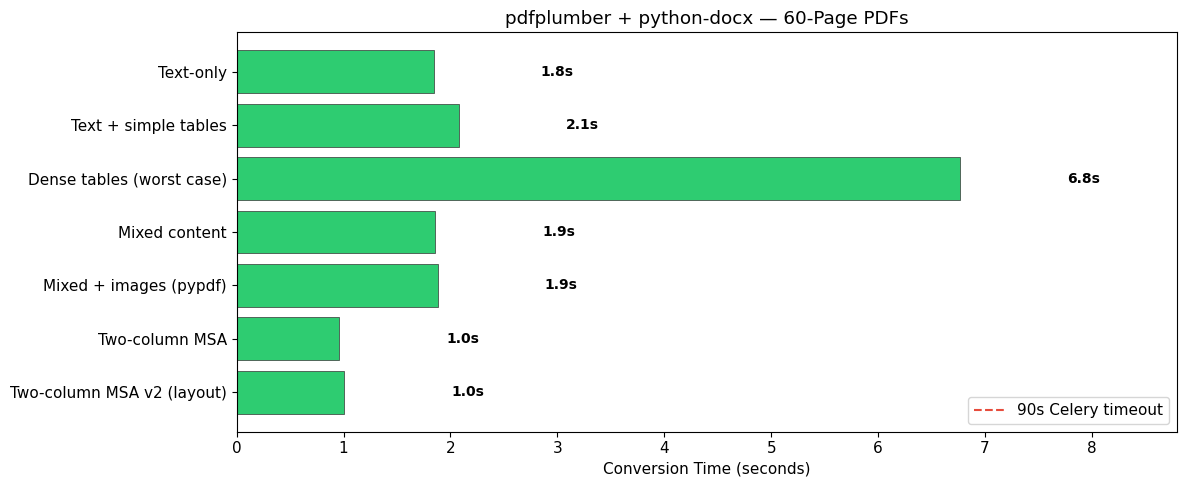

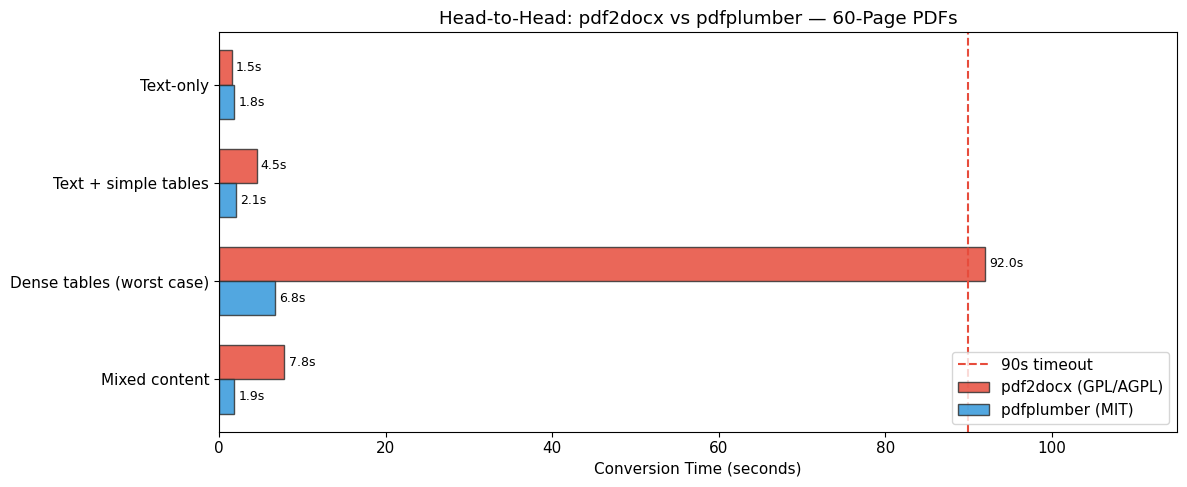


All output files saved to /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/

📁 Output files:
  chart_comparison.png                      71 KB
  chart_pdfplumber_results.png              73 KB
  dense_tables.docx                         50 KB
  dense_tables.pdf                       2,301 KB
  mixed_content.docx                        39 KB
  mixed_content.pdf                        730 KB
  mixed_with_images.docx                    39 KB
  simple_tables.docx                        39 KB
  simple_tables.pdf                        593 KB
  text_only.docx                            41 KB
  text_only.pdf                            398 KB
  two_column_msa.docx                       43 KB
  two_column_msa.pdf                        64 KB
  two_column_msa_v2.docx                    43 KB


In [11]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts. Install with: pip install matplotlib")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})

    # ── Chart 1: pdfplumber results ──
    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    colors_chart = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(scenarios, times, color=colors_chart, edgecolor="#333", linewidth=0.5)
    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title(f"pdfplumber + python-docx — {PAGES}-Page PDFs")
    ax.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(0, max(times) * 1.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "chart_pdfplumber_results.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # ── Chart 2: Side-by-side comparison with pdf2docx ──
    compare_scenarios = [name for name in ["Text-only", "Text + simple tables",
                                            "Dense tables (worst case)", "Mixed content"]]
    pdfplumber_times = []
    pdf2docx_times = []
    for name in compare_scenarios:
        for r in results:
            if r["scenario"] == name:
                pdfplumber_times.append(r["total_s"])
                break
        pdf2docx_times.append(pdf2docx_results[name]["total_s"])

    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(compare_scenarios))
    width = 0.35

    bars1 = ax.barh([i - width/2 for i in x], pdf2docx_times, height=width,
                     color="#e74c3c", alpha=0.85, label="pdf2docx (GPL/AGPL)", edgecolor="#333")
    bars2 = ax.barh([i + width/2 for i in x], pdfplumber_times, height=width,
                     color="#3498db", alpha=0.85, label="pdfplumber (MIT)", edgecolor="#333")

    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
    ax.set_yticks(list(x))
    ax.set_yticklabels(compare_scenarios)
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title(f"Head-to-Head: pdf2docx vs pdfplumber — {PAGES}-Page PDFs")
    ax.legend(loc="lower right")

    for bar, t in zip(bars1, pdf2docx_times):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{t:.1f}s", va="center", fontsize=9)
    for bar, t in zip(bars2, pdfplumber_times):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{t:.1f}s", va="center", fontsize=9)

    ax.set_xlim(0, max(max(pdf2docx_times), max(pdfplumber_times)) * 1.25)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "chart_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nAll output files saved to {OUTPUT_DIR}/")

# ── Print file listing ──
print("\n📁 Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:<35} {size_kb:>8,.0f} KB")

---
## Licensing Summary

| Component | License | Role |
|-----------|---------|------|
| `pdfplumber` | MIT | PDF text & table extraction |
| `python-docx` | MIT | DOCX file generation |
| `pypdf` | BSD-3 | Image extraction from PDFs |
| `pdfminer.six` | MIT | Transitive dep of pdfplumber |

**All components in the conversion pipeline are MIT/BSD.** PyMuPDF (AGPL) is only used for generating synthetic test PDFs — it would NOT be in the production pipeline.

## Tradeoffs vs pdf2docx

| Feature | pdf2docx (GPL/AGPL) | pdfplumber + python-docx (MIT) |
|---------|---------------------|-------------------------------|
| License | GPL v3 / AGPL (PyMuPDF) | MIT + BSD |
| Table detection | Good (rule-based, O(n²) on dense tables) | Good (line intersection, pdfplumber) |
| Image extraction | Yes (PyMuPDF) | Via pypdf (BSD) — less reliable |
| Text positioning | Preserves layout well | Word-level positioning, line reconstruction |
| Font/style mapping | Partial | Manual (font size → heading style) |
| Speed (text) | Fast (C-based PyMuPDF) | Slower (pure Python pdfminer) |
| Speed (tables) | Degrades O(n²) on dense tables | TBD — see results above |
| Maintenance | ArtifexSoftware maintained | Active community |
| Install | `pip install pdf2docx` | `pip install pdfplumber python-docx pypdf` |

## Known Limitations of pdfplumber approach

1. **No native image extraction** — must pair with pypdf or pikepdf
2. **No font embedding** — extracted text uses system fonts in DOCX
3. **No header/footer detection** — would need custom logic
4. **No multi-column layout detection** — text is extracted left-to-right by y-position
5. **Pure Python** — inherently slower than C-based pdf2docx for raw parsing